1. Імпорт бібліотек та налаштування

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків для гарного вигляду
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

2. Зчитування та Data Cleaning

In [2]:
# Завантаження датасету
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# Файл розділений пробілами різної довжини
df = pd.read_csv(url, sep=r'\s+', names=column_names, na_values='?')

print("Розмір до очищення:", df.shape)

# DATA CLEANING: 
# 1. Видаляємо рядки з відсутніми даними (Missing Values)
df = df.dropna()

# 2. Перетворюємо horsepower у числовий формат (float)
df['horsepower'] = df['horsepower'].astype(float)

# 3. Перетворюємо origin (1, 2, 3) у зрозумілі категорії для красивих графіків
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin'] = df['origin'].map(origin_map)

print("Розмір після очищення:", df.shape)
display(df.sample(5))

Розмір до очищення: (398, 9)
Розмір після очищення: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
54,35.0,4,72.0,69.0,1613.0,18.0,71,Japan,datsun 1200
245,36.1,4,98.0,66.0,1800.0,14.4,78,USA,ford fiesta
5,15.0,8,429.0,198.0,4341.0,10.0,70,USA,ford galaxie 500
161,16.0,6,250.0,105.0,3897.0,18.5,75,USA,chevroelt chevelle malibu
301,34.2,4,105.0,70.0,2200.0,13.2,79,USA,plymouth horizon


3. Графік 1 — Залежність (Scatter plot)

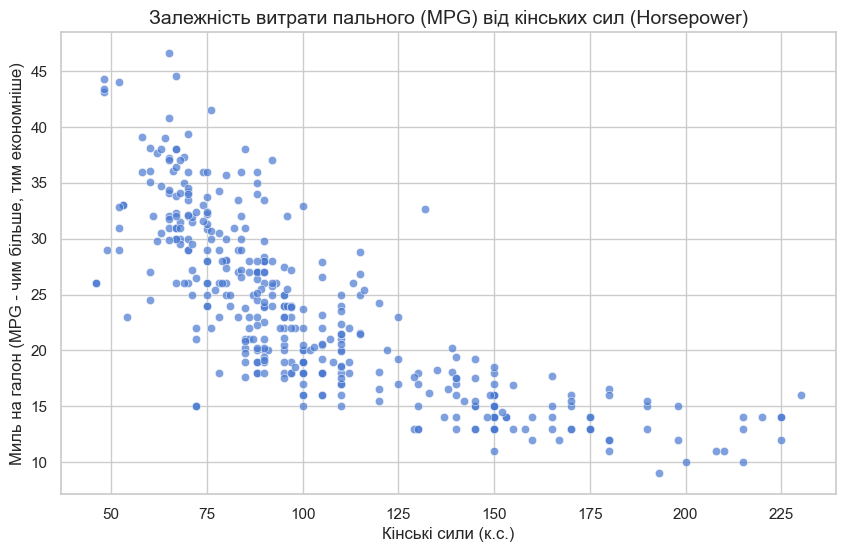

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='horsepower', y='mpg', alpha=0.7, color='b')
plt.title('Залежність витрати пального (MPG) від кінських сил (Horsepower)', fontsize=14)
plt.xlabel('Кінські сили (к.с.)')
plt.ylabel('Миль на галон (MPG - чим більше, тим економніше)')
plt.show()

4. Графік 2 — Гістограма з 5 діапазонами

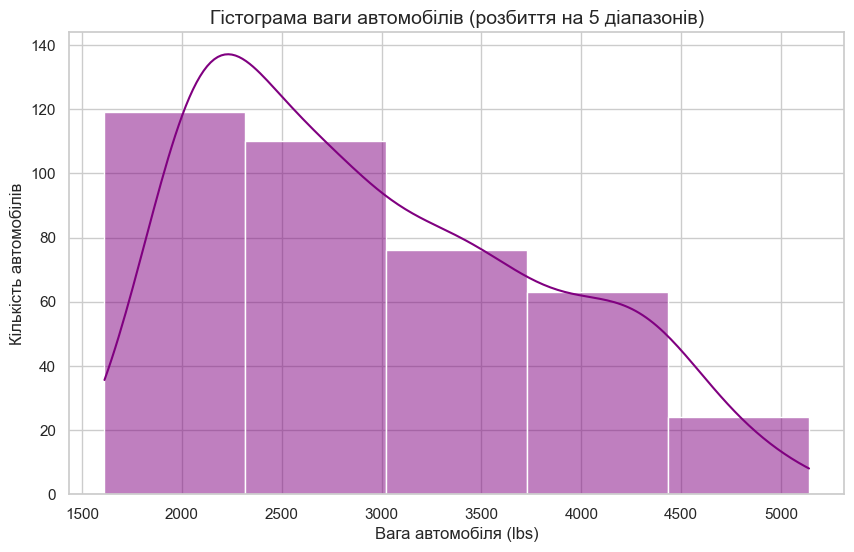

In [4]:
plt.figure(figsize=(10, 6))
# Параметр bins=5 чітко розбиває дані на 5 кошиків
sns.histplot(data=df, x='weight', bins=5, kde=True, color='purple')
plt.title('Гістограма ваги автомобілів (розбиття на 5 діапазонів)', fontsize=14)
plt.xlabel('Вага автомобіля (lbs)')
plt.ylabel('Кількість автомобілів')
plt.show()

5. Графік 3 — Багатовимірна візуалізація 3D

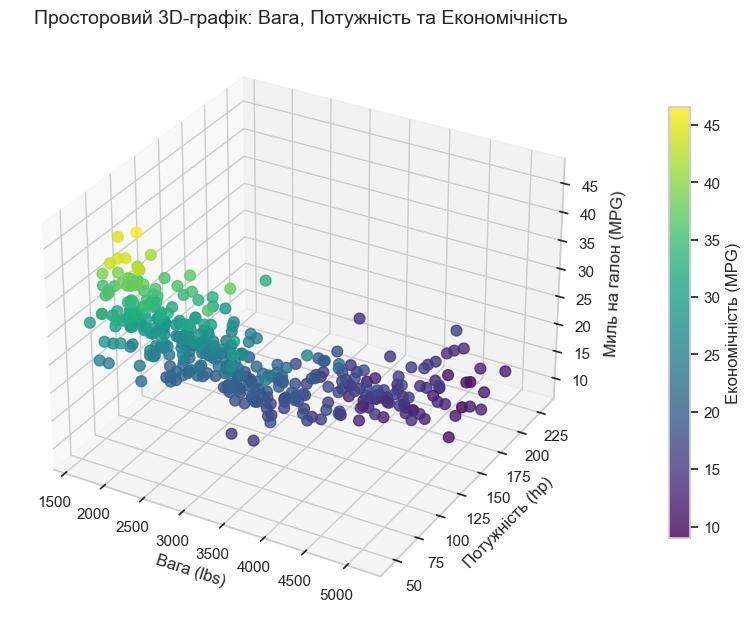

In [5]:
import matplotlib.pyplot as plt

# Створюємо фігуру та додаємо 3D-проєкцію
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3 реальні виміри для осей X, Y та Z
x = df['weight']
y = df['horsepower']
z = df['mpg']

# Будуємо 3D Scatter plot (колір також залежить від MPG для краси)
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=60, alpha=0.8)

# Налаштовуємо підписи осей
ax.set_title('Просторовий 3D-графік: Вага, Потужність та Економічність', fontsize=14)
ax.set_xlabel('Вага (lbs)')
ax.set_ylabel('Потужність (hp)')
ax.set_zlabel('Миль на галон (MPG)')

# Додаємо кольорову шкалу
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Економічність (MPG)')

plt.show()

6. Графік 4 — Багатовимірна візуалізація (4D Bubble Chart)

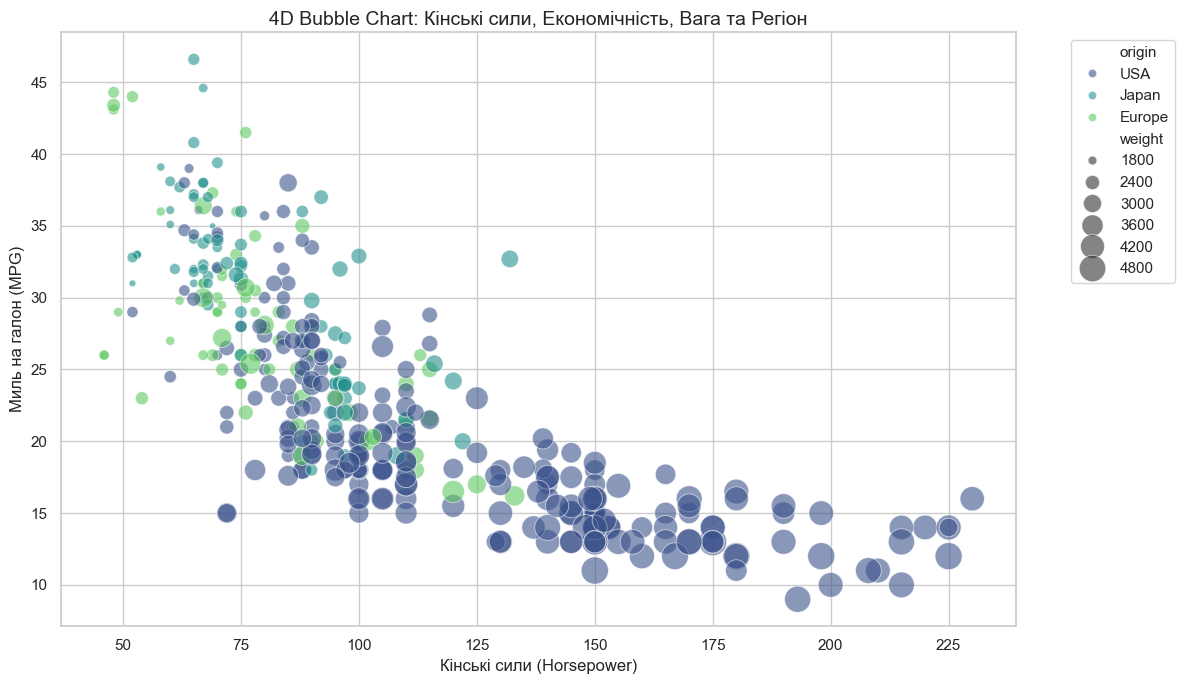

In [6]:
plt.figure(figsize=(12, 7))
# 4 виміри: x=horsepower, y=mpg, колір(hue)=origin, розмір(size)=weight
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin', size='weight', 
                sizes=(20, 400), alpha=0.6, palette='viridis')
plt.title('4D Bubble Chart: Кінські сили, Економічність, Вага та Регіон', fontsize=14)
plt.xlabel('Кінські сили (Horsepower)')
plt.ylabel('Миль на галон (MPG)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

7. Графік 5 — Категоріальна багатовимірність (Violin Plot)

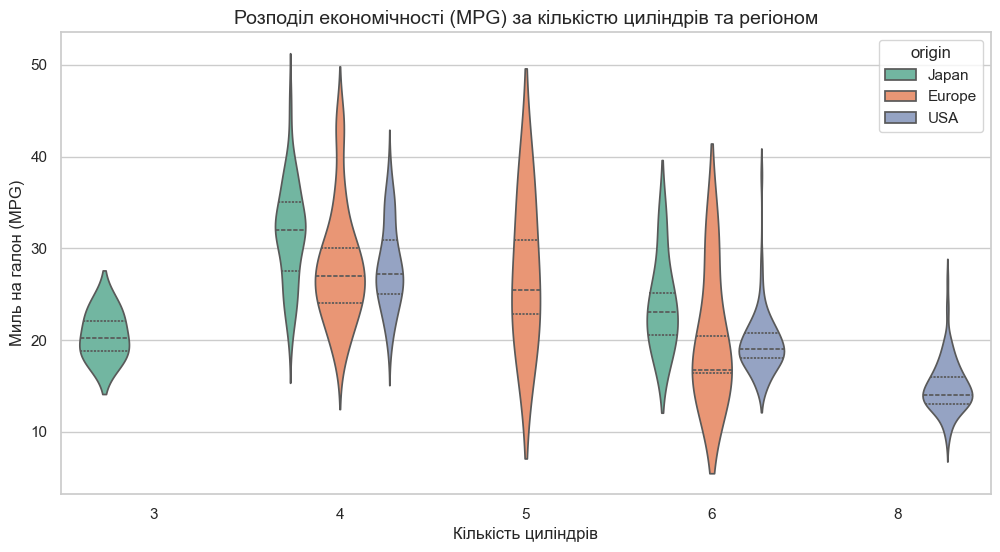

In [7]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='cylinders', y='mpg', hue='origin', palette='Set2', inner='quartile')
plt.title('Розподіл економічності (MPG) за кількістю циліндрів та регіоном', fontsize=14)
plt.xlabel('Кількість циліндрів')
plt.ylabel('Миль на галон (MPG)')
plt.show()

8: Графік 6 — Теплова карта кореляції (Heatmap)

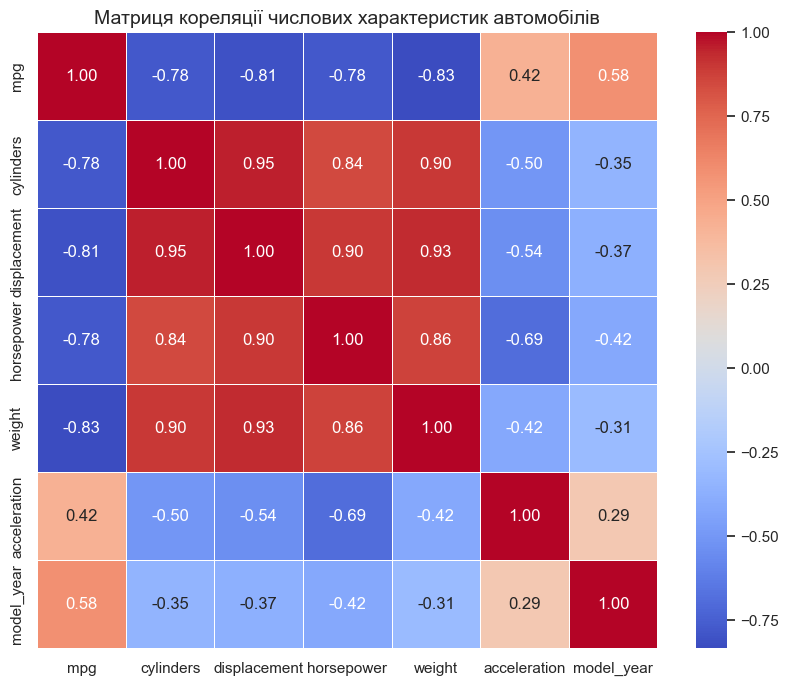

In [8]:
plt.figure(figsize=(10, 8))
# Вибираємо тільки числові колонки для матриці кореляції
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляції числових характеристик автомобілів', fontsize=14)
plt.show()

9: Новий графік (Pairplot)

<Figure size 1200x1000 with 0 Axes>

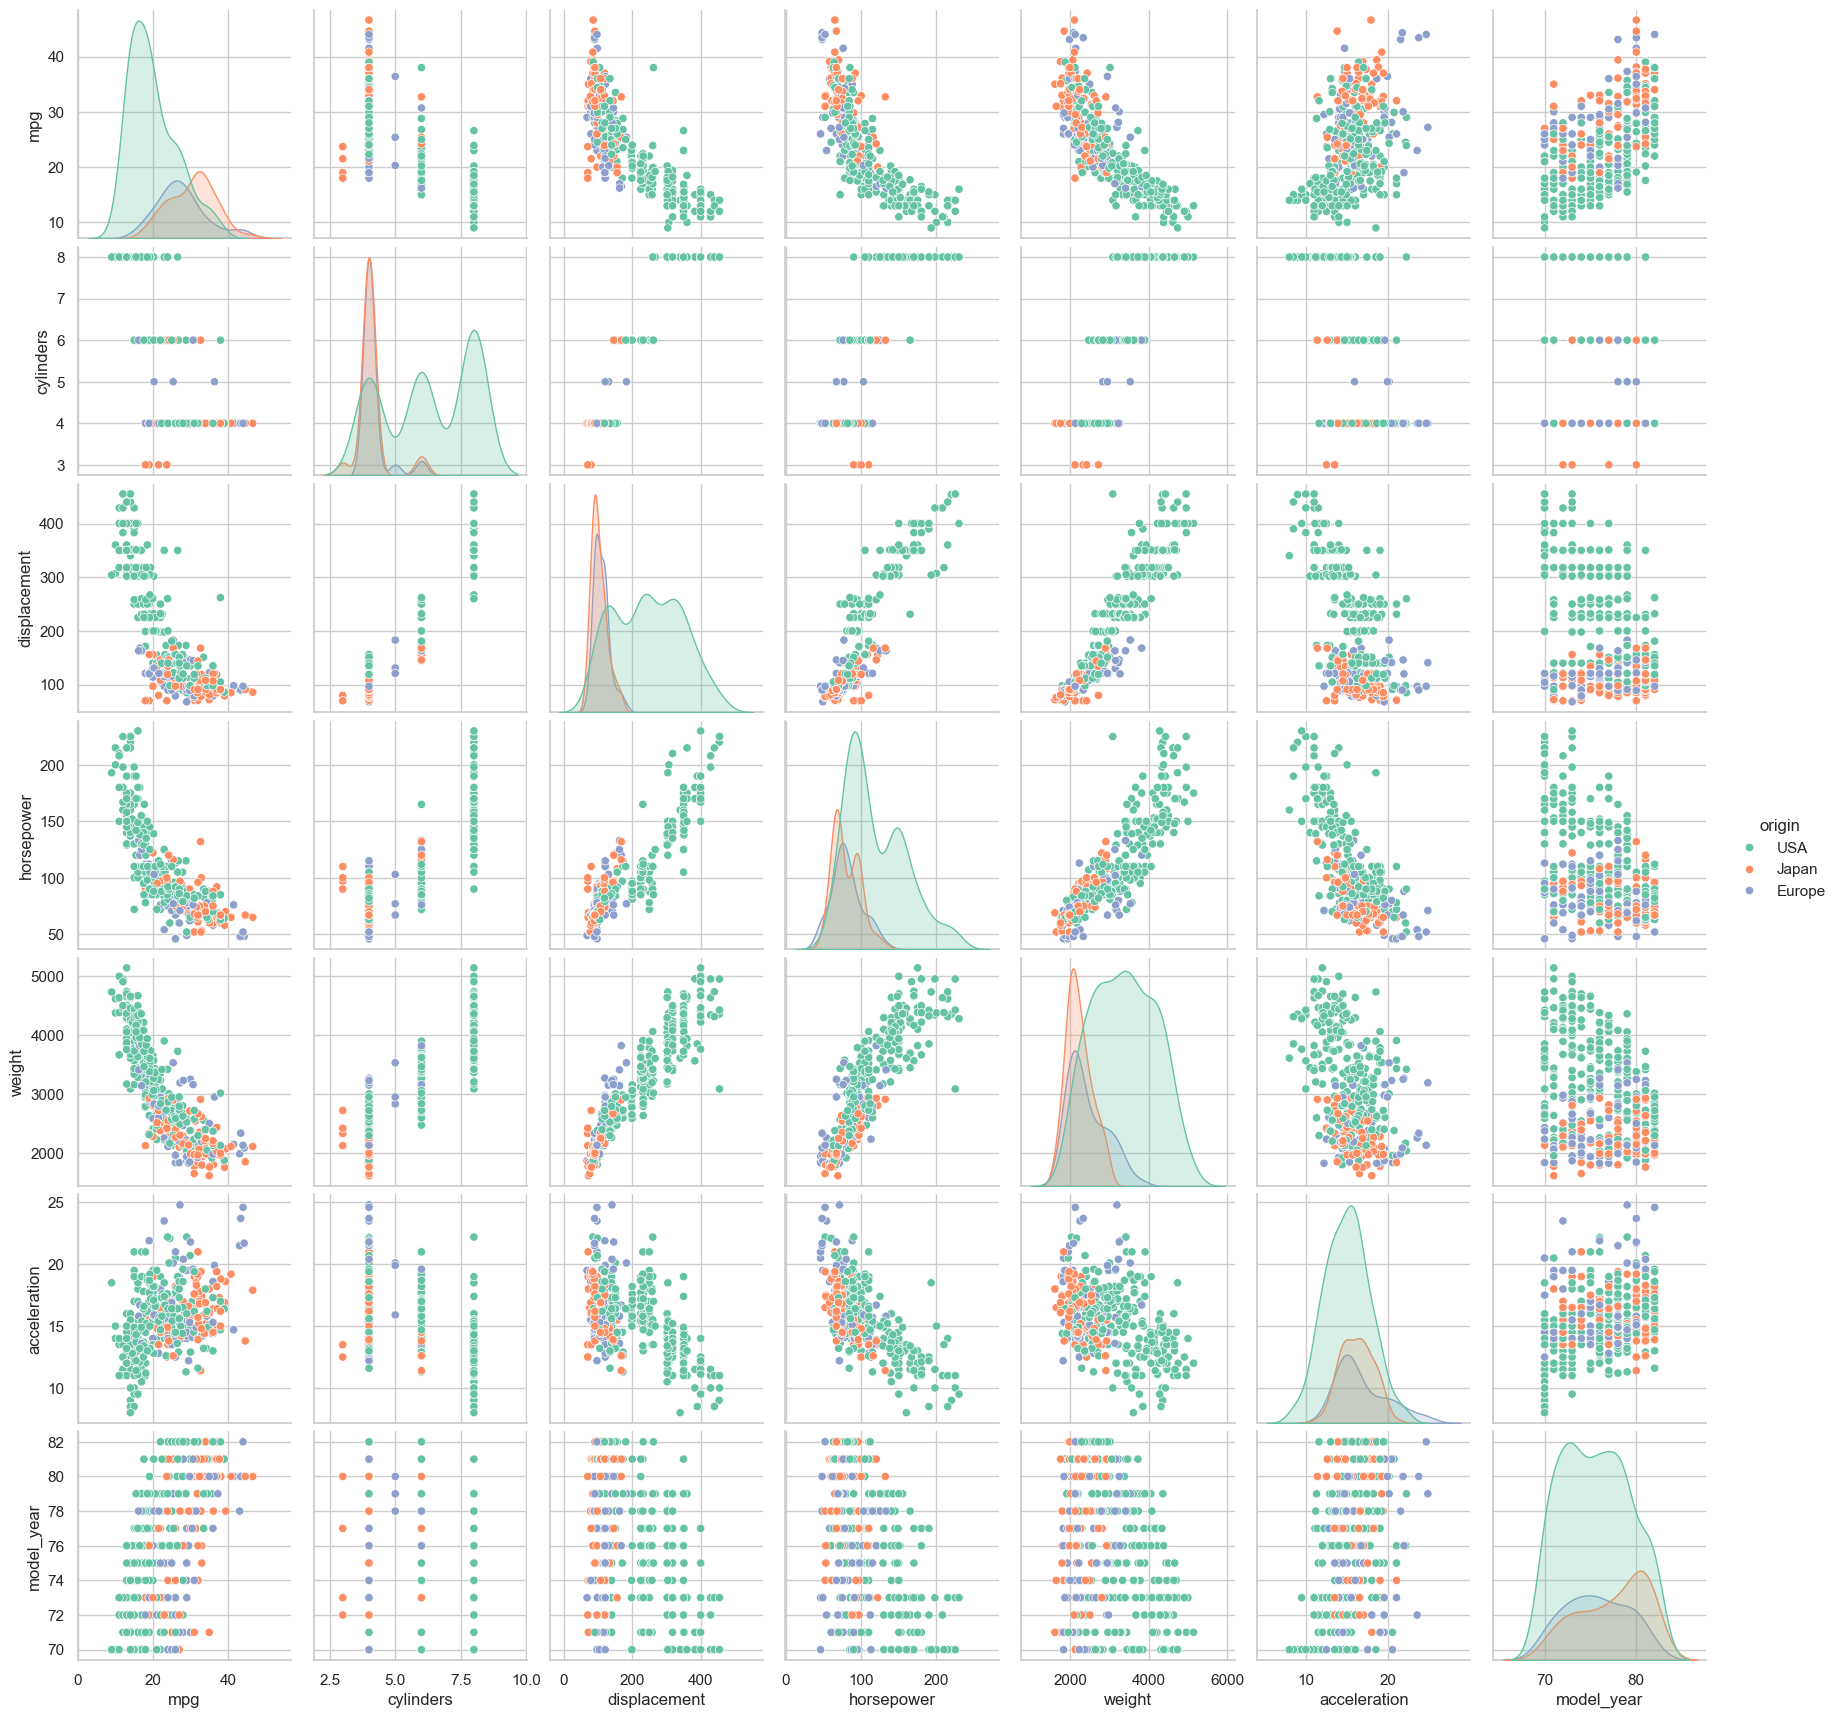

In [9]:
# Додатковий графік: Pairplot — Матриця діаграм розсіяння
import warnings

plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='origin', palette='Set2')
plt.show()